In [1]:
# Simple Regression 
# always type the code along , so u can learn it 

In [58]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import statsmodels 
import statsmodels.api as sm

#import scikit-learn # install this, but imort below  
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [6]:
# read the data 
advertising = pd.read_csv('advertising.csv')
advertising.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
advertising.shape

(200, 4)

In [8]:
advertising.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
advertising.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


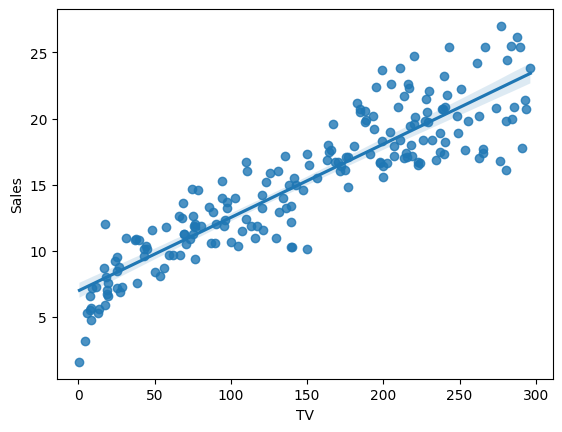

In [21]:
# visualize the data 
sns.regplot(x='TV',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
plt.show()

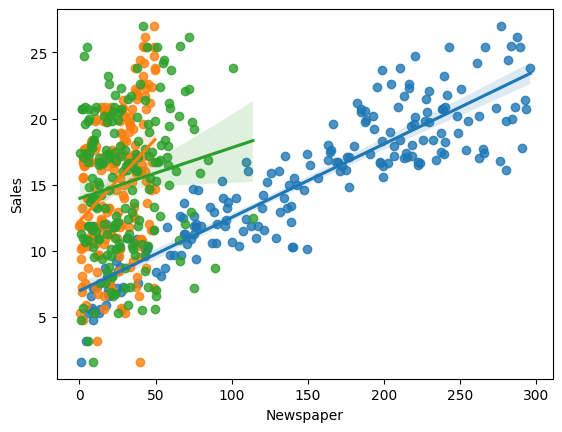

In [18]:
# visualize the data 
sns.regplot(x='TV',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
sns.regplot(x='Radio',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
sns.regplot(x='Newspaper',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
plt.show()

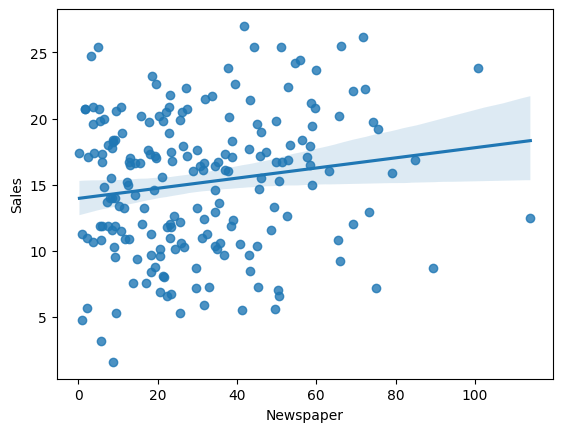

In [19]:
# visualize the data 
#sns.regplot(x='TV',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
#sns.regplot(x='Radio',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
sns.regplot(x='Newspaper',y='Sales',data=advertising) # y='sales' invalid, y='Sales', valid 
plt.show()

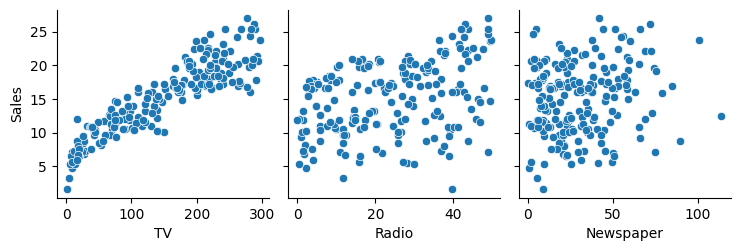

In [20]:
# 
sns.pairplot(
    data = advertising,
    x_vars=['TV','Radio','Newspaper'],
    y_vars='Sales'
)

In [22]:
# Correlation between the variable
advertising.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


<Axes: >

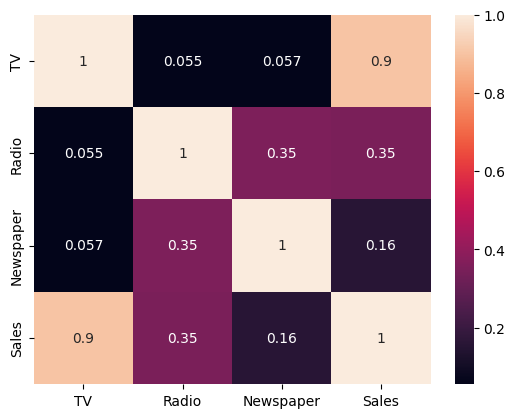

In [23]:
#
sns.heatmap(advertising.corr(),annot=True)

# The darker shade less correlation 0.2
# The Lighter shade more co-related 1.0

# see the correlation between [ TV vs sales, NP vs sales, Radio vs sales]

# Steps 
* Create X & Y 
* Create train and test sets(70-30, 80-20)
* Train your model on training sets(i.e learn the coefficiet)
* evaluate the model( trainings set, train set)

In [28]:
# create X and y
X = advertising['TV']
y = advertising['Sales']

In [33]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.70,random_state=100)
X_train.shape
X_test.shape

(60,)

In [35]:
y_train.shape

(140,)

In [36]:
X_test.head()

126      7.8
104    238.2
99     135.2
92     217.7
111    241.7
Name: TV, dtype: float64

In [37]:
# Training the Model 
X_train_sm = sm.add_constant(X_train)
X_train_sm.head()

,const,TV
74,1.0,213.4
3,1.0,151.5
185,1.0,205.0
26,1.0,142.9
90,1.0,134.3


In [ ]:
# y = c+ m1.x1
# y = c.X0 + 
# y = c.const + m1.TV ( where constant is 1)

In [39]:
# Fitting the model (Ordinary Least Square)
lr = sm.OLS(y_train, X_train_sm)
lr_model = lr.fit()
lr_model.params

const    6.948683
TV       0.054546
dtype: float64

In [40]:
# Sales = 6.94 + 0.05.TV 
# Co-efficient of TV is positive 
# INtesect is +ve number (6.94) , if u dont spend on tv advertisment , still you will get sales 

In [41]:
lr_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Sat, 31 Aug 2024   Prob (F-statistic):           1.52e-52
Time:                        16:06:31   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.000       6.188       7.709
TV             0.0545      0.002     24.722      0.000       0.050       0.059
==============================================================================
Omnibus:                        0.027   Durbin-Watson:                   2.196
Prob(Omnibus):                  0.987   Jarque-Bera (JB):                0.150
Skew:                          -0.006   Prob(JB):                        0.928
Kurtosis:                       2.840   Cond. No.                         328.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [42]:
# const: coeffient 
# Predictory variable: TV 
# P-value: o means , both are coeff are significant
# R-Squared : 81% : means The R-squared value is high and hence, the model explain much of the variance.
# Prob(F-statistic): 

In [43]:
# 1. coeff and p-value 
# 2. R-squared is 81.6% , very high
# 3. F-statistic 
# 4. p(F-statistic ) is low => the fit is not by chance

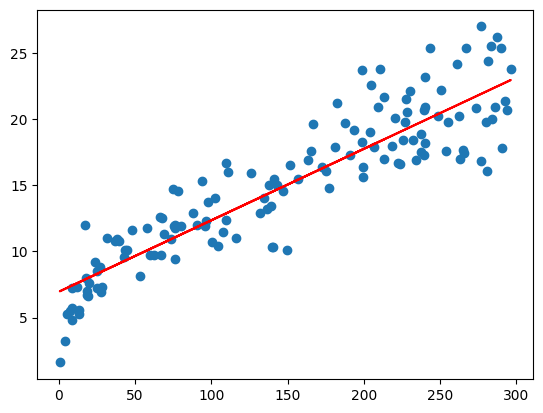

In [46]:
plt.scatter(X_train,y_train)
# againt this what is model prediting 
#plt.plot(X_train, const + coeff*TV)
plt.plot(X_train, 6.948 + 0.054*X_train , 'r')
plt.show()

### Step 3: Residual Analysis

In [47]:
# error = f(y_train, y_train_pred)

In [48]:
y_train_pred = lr_model.predict(X_train_sm)
y_train_pred

74     18.588747
3      15.212365
185    18.130563
26     14.743271
90     14.274178
         ...    
87     12.986898
103    17.197830
67     14.546907
24     10.346884
8       7.417777
Length: 140, dtype: float64

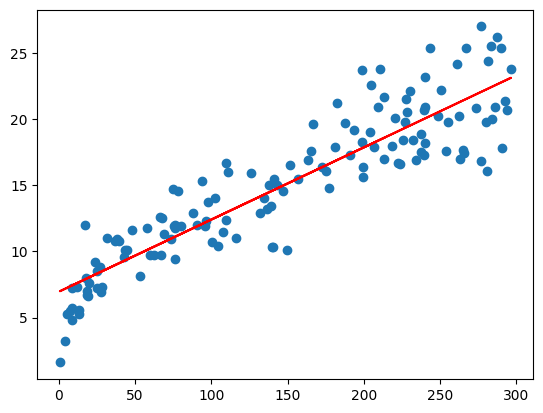

In [49]:
plt.scatter(X_train,y_train)
plt.plot(X_train, y_train_pred , 'r')
plt.show()

In [ ]:
# Erroe analysis 

In [51]:
res = y_train - y_train_pred

/var/folders/kk/vsk5n5vj28n42f90qn__wm7w0000gn/T/ipykernel_3840/733060840.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(res)


Text(0.5, 1.0, 'Residual Plot')

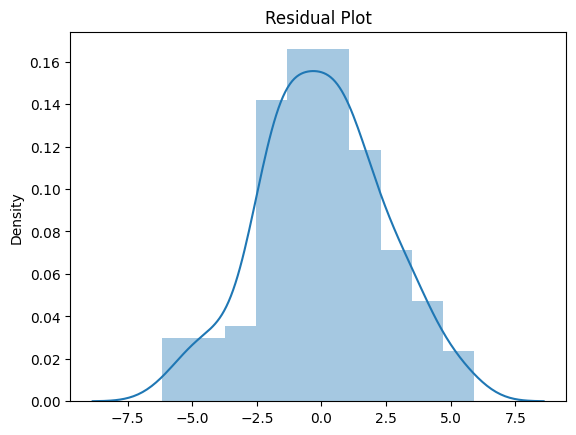

In [52]:
# Plot the residuals 
plt.figure()
sns.distplot(res)
plt.title("Residual Plot")

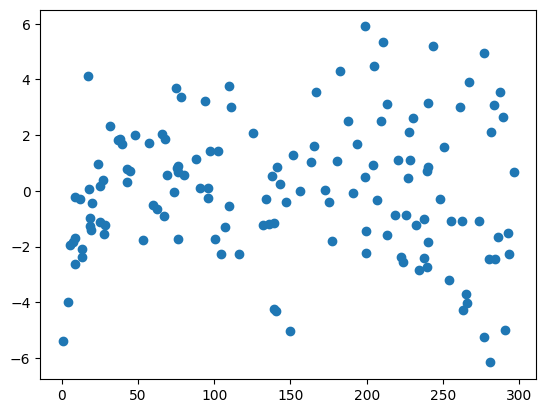

In [53]:
# Look for patterns in residuals ( we should not be able to identify)
plt.scatter(X_train,res)
plt.show()

### Step 4: Predictions and Evaluation on the Test Set

In [54]:
# prediction on the test set (y_test_pred)
# Evaluate the model , r-squared , on the test 

In [61]:
# add a const/intercept to test 
X_test_sm = sm.add_constant(X_test)

# pred on test 
y_test_pred = lr_model.predict(X_test_sm)

In [62]:
# Evaluate the model , r-squared , on the test 
# r-squared
r2 = r2_score(y_true=y_test,y_pred=y_test_pred)
r2

0.792103160124566

In [63]:
# r-squared on training 
r2_score(y_true=y_train,y_pred=y_train_pred)

0.8157933136480389

In [64]:
#help(r2_score)

In [65]:
# mean squared error 
mean_squared_error(y_true=y_train,y_pred=y_train_pred)

np.float64(5.752400386486836)

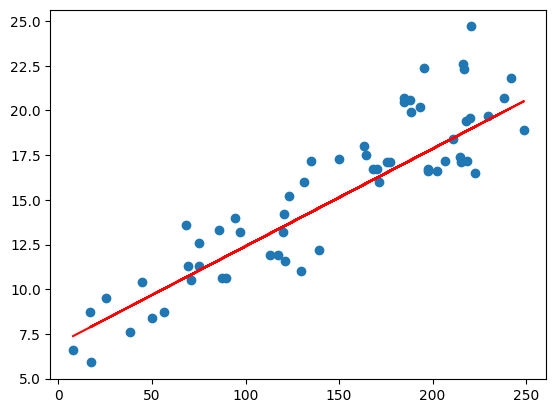

In [66]:
# visualize on preo
plt.scatter(X_test,y_test)
plt.plot(X_test, y_test_pred , 'r')
plt.show()

### Linear Regression Using SKLearn --- Sii-kit-learn

In [67]:
# train test split 
X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.70,random_state=100)

In [74]:
X_train.shape # series on array
# reshae tp (140,1)

X_train_lm = X_train.values.reshape(-1,1) # if u dont know the shape , like we know here 
X_train_lm.shape

X_test_lm = X_test.values.reshape(-1,1) # if u dont know the shape , like we know here 
X_test_lm.shape

(60, 1)

In [68]:
# Steps in sklearn model building 
# 1. Create an object of linear regression 
# 2. fit the model
# 3. see the params , make predictions( train,test)
# 4. evaluate (r2,etc.)

In [77]:
# 1. Create an object of linear regression 
from sklearn.linear_model import LinearRegression

lm = LinearRegression()

# 2. fit the model
lm.fit(X_train_lm,y_train)

LinearRegression()

In [78]:
help(lm)

Help on LinearRegression in module sklearn.linear_model._base object:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)
 |  
 |  Ordinary least squares Linear Regression.
 |  
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |  
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |  
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |  
 |  n_jobs : int, default=None
 |      The number of jobs to use for the computation. This will only provide
 | 

In [79]:
# 3. see the params , make predictions( train,test)
print(lm.coef_)
print(lm.intercept_)

[0.05454575]
6.948683200001357


In [80]:
# make predictions 
y_train_pred = lm.predict(X_train_lm)
y_test_pred = lm.predict(X_test_lm)

In [81]:
# 4. evaluate the models (r2,etc.)
print(r2_score(y_true=y_train,y_pred=y_train_pred))
print(r2_score(y_true=y_test,y_pred=y_test_pred))

0.8157933136480389
0.7921031601245662
